In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

restock_df = pd.read_csv("../data/restock_recommendations.csv")

restock_df.head()

,store,product,forecast_sales,inventory,safety_stock,recommended_restock
0,Akola,bread,259.277777,70,51.855555,241.0
1,Akola,eggs,369.713589,91,73.942718,353.0
2,Akola,milk,528.499805,132,105.699961,502.0
3,Akola,oil,544.324177,125,108.864835,528.0
4,Akola,onion,260.365345,80,52.073069,232.0


Top Products Needing Restock

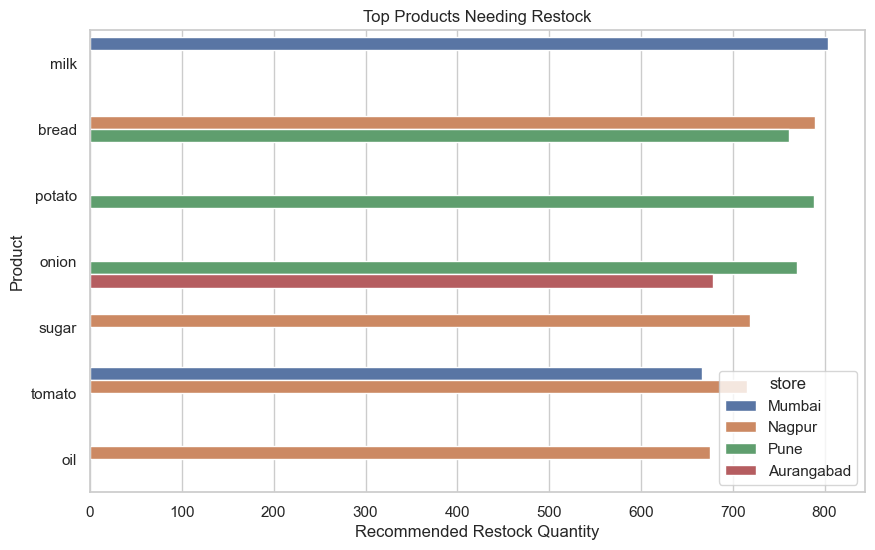

In [2]:
top_restock = restock_df.sort_values("recommended_restock", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_restock,
    x="recommended_restock",
    y="product",
    hue="store"
)

plt.title("Top Products Needing Restock")
plt.xlabel("Recommended Restock Quantity")
plt.ylabel("Product")

plt.savefig("../docs/top_restock_products.png")

plt.show()

Store-Level Restock Demand

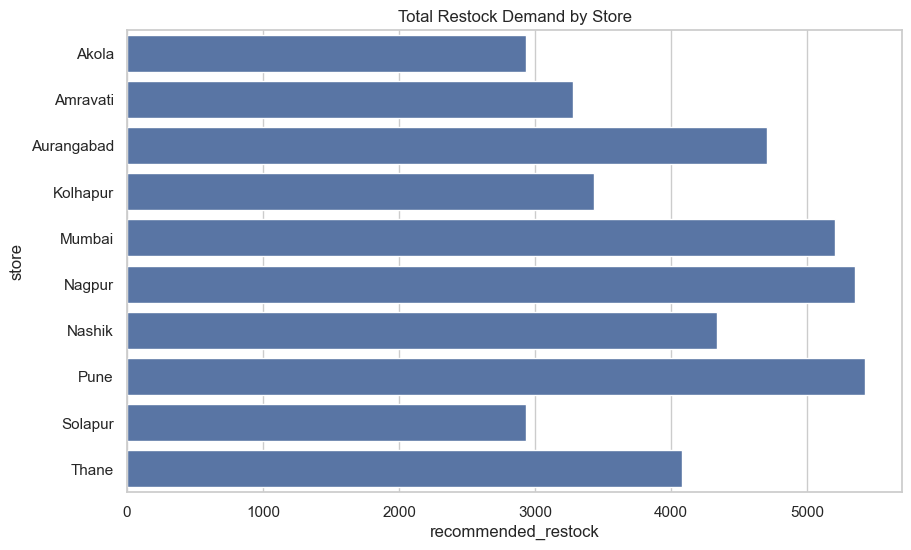

In [3]:
store_restock = restock_df.groupby("store")["recommended_restock"].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=store_restock,
    x="recommended_restock",
    y="store"
)

plt.title("Total Restock Demand by Store")

plt.savefig("../docs/store_restock_demand.png")

plt.show()

Heatmap shows store vs product restock intensity.

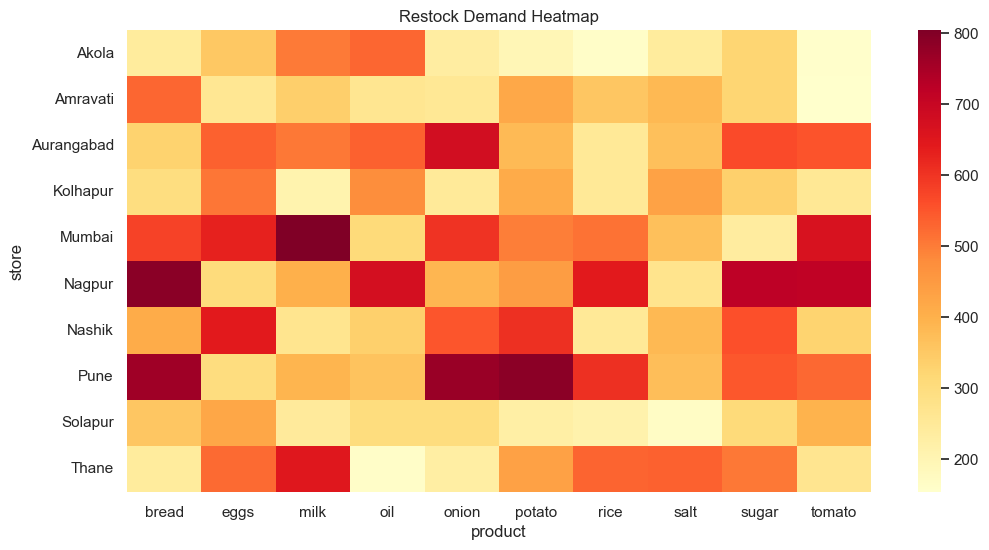

In [4]:
pivot = restock_df.pivot_table(
    values="recommended_restock",
    index="store",
    columns="product",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="YlOrRd"
)

plt.title("Restock Demand Heatmap")

plt.savefig("../docs/restock_heatmap.png")

plt.show()

Products at Risk of Stockout

In [5]:
risk_products = restock_df[restock_df["recommended_restock"] > 0]

risk_products.sort_values("recommended_restock", ascending=False).head(10)

,store,product,forecast_sales,inventory,safety_stock,recommended_restock
42,Mumbai,milk,758.614929,106,151.722986,804.0
50,Nagpur,bread,738.659999,96,147.732000,790.0
75,Pune,potato,788.055237,158,157.611047,788.0
74,Pune,onion,722.989687,98,144.597937,770.0
70,Pune,bread,760.153518,151,152.030704,761.0
58,Nagpur,sugar,743.721281,173,148.744256,719.0
59,Nagpur,tomato,712.391310,140,142.478262,715.0
24,Aurangabad,onion,635.764072,85,127.152814,678.0
53,Nagpur,oil,697.270826,162,139.454165,675.0
49,Mumbai,tomato,672.905913,141,134.581183,666.0
